In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split



df = pd.read_csv("./content/all_stocks_5yr.csv")

# EDA

In [100]:
# 1. ดู 5 แถวแรกของข้อมูล
display(df.head())

# 2. ดูโครงสร้างข้อมูล และประเภทของคอลัมน์ (เพื่อตรวจสอบว่า date เป็น datetime หรือยัง)
display(df.info())

# 3. ดูค่าสถิติพื้นฐาน (Mean, Max, Min, Std)
display(df.describe())

# 4. ตรวจสอบว่ามีข้อมูลสูญหาย (Missing Values) หรือไม่
display(df.isnull().sum())

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


None

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

In [101]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Variables:")
for col in numerical_cols:
    print(f"- {col}")

print("\nCategorical Variables:")
for col in categorical_cols:
    print(f"- {col}")

Numerical Variables:
- open
- high
- low
- close
- volume

Categorical Variables:
- date
- Name


In [102]:
print("Unique values in categorical columns:")
print("=" * 40)
for col in categorical_cols:
    num_unique = df[col].nunique()
    if num_unique <= 12:
        unique_vals = df[col].unique().tolist()
        print(f"{col}: {num_unique} ค่า ได้แก่ {unique_vals}")
    else:
        print(f"{col}: {num_unique} ค่า")


Unique values in categorical columns:
date: 1259 ค่า
Name: 505 ค่า


In [103]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)

Empty DataFrame
Columns: [date, open, high, low, close, volume, Name]
Index: []


In [104]:
print("\n--- 🚨 ตรวจสอบค่าติดลบใน Numerical Variables ---")
has_negative = False

for col in numerical_cols:
    negative_rows = df[df[col] < 0]

    if not negative_rows.empty:
        print(f"⚠️ พบค่าติดลบในคอลัมน์ '{col}':")
        print(negative_rows[['date', col]])
        has_negative = True

if not has_negative:
    print("✅ ข้อมูลปกติ: ไม่พบค่าติดลบในคอลัมน์ตัวเลขเลยครับ")


--- 🚨 ตรวจสอบค่าติดลบใน Numerical Variables ---
✅ ข้อมูลปกติ: ไม่พบค่าติดลบในคอลัมน์ตัวเลขเลยครับ


In [105]:
# สมมติว่า df ของคุณมีข้อมูลหุ้นหลายตัวแล้ว
# df = pd.read_csv('all_stocks_5yr.csv')

numerical_cols = ['open', 'high', 'low', 'close', 'volume']

# 1. สร้างฟังก์ชันเช็ก Outlier ด้วย IQR (รับค่าเป็น Series ของหุ้นแต่ละตัว)
def check_outlier(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # คืนค่าเป็น True ถ้าเป็น Outlier, False ถ้าปกติ
    return (x < lower_bound) | (x > upper_bound)

# 2. ใช้ groupby('Name') เพื่อให้ฟังก์ชันคำนวณแยกตามหุ้น
# .transform() จะช่วยคำนวณและแปะค่ากลับไปที่แถวเดิมของ DataFrame
outlier_masks = df.groupby('Name')[numerical_cols].transform(check_outlier)

# เปลี่ยนชื่อคอลัมน์ให้สื่อความหมาย (เช่น 'close' -> 'outlier_close')
outlier_masks.columns = [f'outlier_{col}' for col in numerical_cols]

# เอาผลลัพธ์ไปแปะรวมกับ df เดิมเพื่อดูง่ายๆ
df_with_outliers = pd.concat([df, outlier_masks], axis=1)

# 3. ลองกรองดูว่าตอนนี้มี Outlier จริงๆ (ที่ผิดปกติสำหรับหุ้นตัวนั้นๆ) กี่แถว
real_outliers_close = df_with_outliers[df_with_outliers['outlier_close'] == True]

print(f"เจอ Outlier ของราคาปิด (ที่เทียบกับตัวเองแล้ว) จำนวน: {len(real_outliers_close)} แถว")

เจอ Outlier ของราคาปิด (ที่เทียบกับตัวเองแล้ว) จำนวน: 9934 แถว


In [106]:
# นับจำนวนบริษัทหุ้น (Name) ที่ไม่ซ้ำกัน ในกลุ่มที่เกิด Outlier
outlier_stock_count = real_outliers_close['Name'].nunique()
print(f"จาก 9,934 แถว พบว่าเป็นของหุ้นจำนวน: {outlier_stock_count} บริษัท")

# ดูสัดส่วน % ของ Outlier เทียบกับข้อมูลทั้งหมด
total_rows = len(df)
percent_outliers = (len(real_outliers_close) / total_rows) * 100
print(f"คิดเป็น {percent_outliers:.2f}% ของข้อมูลทั้งหมด {total_rows} แถว")

จาก 9,934 แถว พบว่าเป็นของหุ้นจำนวน: 184 บริษัท
คิดเป็น 1.60% ของข้อมูลทั้งหมด 619040 แถว



--- 📈 2. กราฟ Time Series แบบ Subplots (เปรียบเทียบหุ้น 3 กลุ่ม) ---


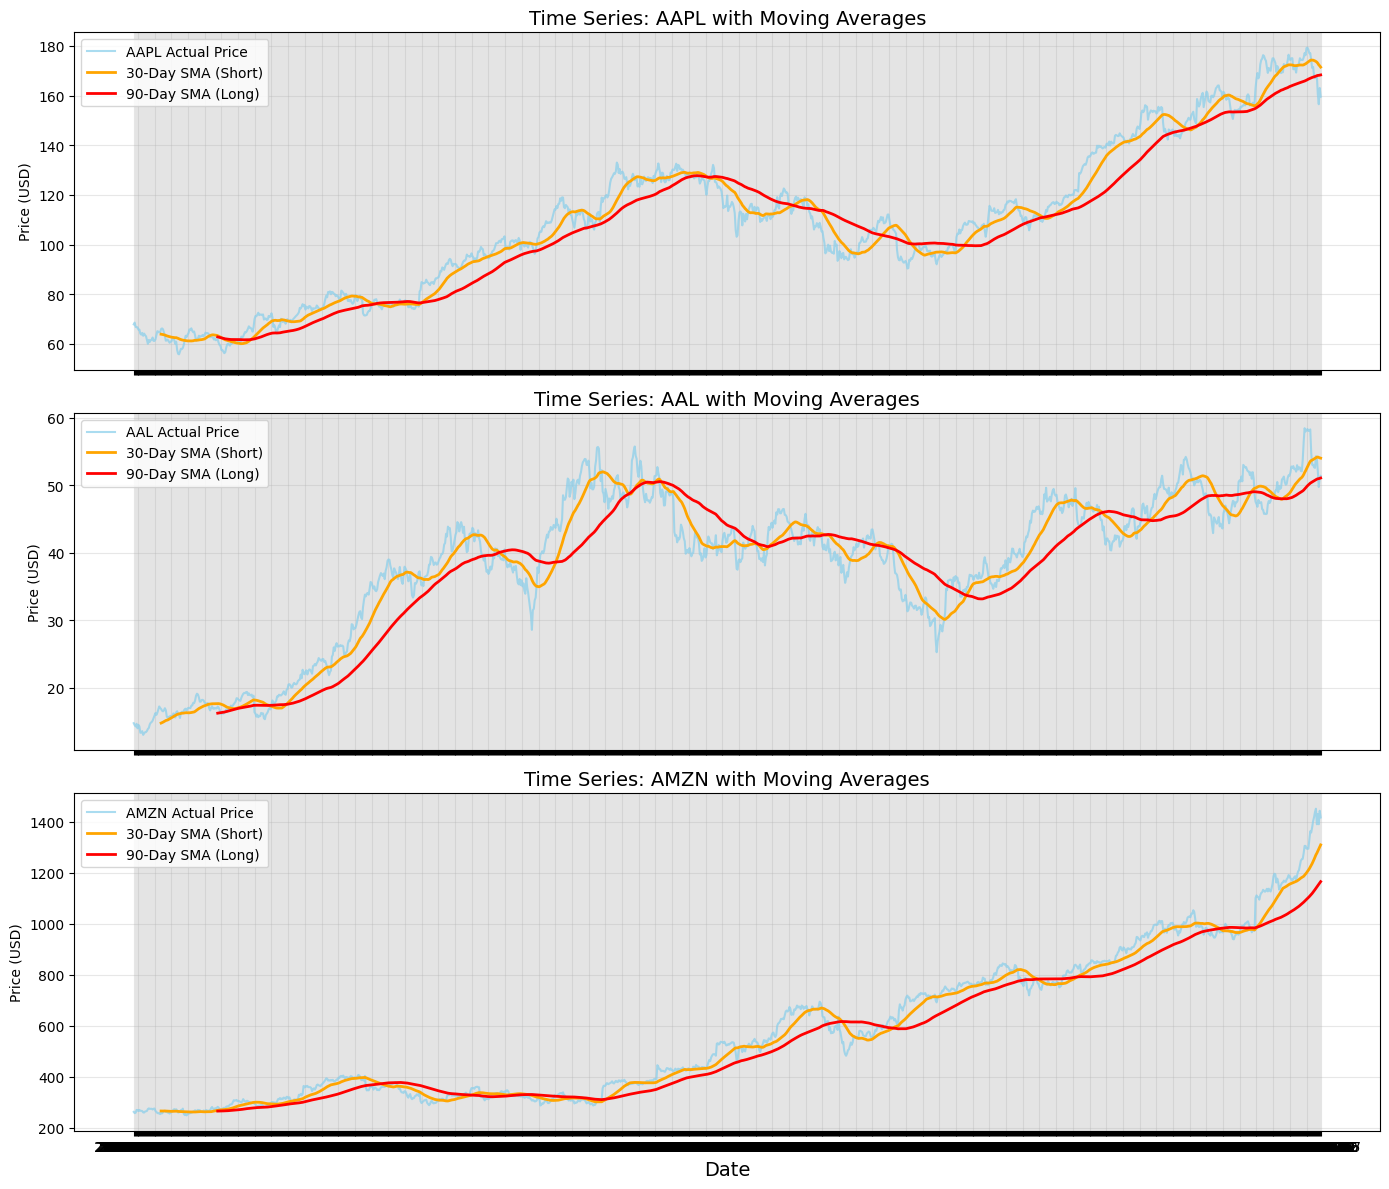

In [107]:
print("\n--- 📈 2. กราฟ Time Series แบบ Subplots (เปรียบเทียบหุ้น 3 กลุ่ม) ---")

# 1. เลือกหุ้นตัวแทนมา 3 ตัว (เช่น Tech, Airlines, Retail)
stocks_to_plot = ['AAPL', 'AAL', 'AMZN']

# 2. สร้างกระดานวาดกราฟแบบ 3 แถว 1 คอลัมน์ (sharex=True คือให้ใช้แกนวันที่ร่วมกัน)
fig, axes = plt.subplots(len(stocks_to_plot), 1, figsize=(14, 12), sharex=True)

# 3. วนลูปวาดกราฟทีละตัว
for i, stock in enumerate(stocks_to_plot):
    # กรองข้อมูลและเซ็ต Index
    df_stock = df[df['Name'] == stock].copy()
    df_stock.set_index('date', inplace=True)
    df_stock.sort_index(inplace=True)

    # คำนวณเส้น SMA
    df_stock['SMA_30'] = df_stock['close'].rolling(window=30).mean()
    df_stock['SMA_90'] = df_stock['close'].rolling(window=90).mean()

    # พลอตลงในช่อง (axes) ของหุ้นตัวนั้นๆ
    axes[i].plot(df_stock.index, df_stock['close'], label=f'{stock} Actual Price', color='skyblue', alpha=0.7)
    axes[i].plot(df_stock.index, df_stock['SMA_30'], label='30-Day SMA (Short)', color='orange', linewidth=2)
    axes[i].plot(df_stock.index, df_stock['SMA_90'], label='90-Day SMA (Long)', color='red', linewidth=2)

    # ตกแต่งแต่ละชั้น
    axes[i].set_title(f'Time Series: {stock} with Moving Averages', fontsize=14)
    axes[i].set_ylabel('Price (USD)', fontsize=10)
    axes[i].legend(loc='upper left', fontsize=10)
    axes[i].grid(True, alpha=0.3)

# ตกแต่งภาพรวม
plt.xlabel('Date', fontsize=14)
plt.tight_layout()
plt.show()


--- 📊 3.2 Initial EDA: Smart Box Plot (Auto-detect Outliers & Percentage) ---
🚨 สรุป: พบหุ้นที่มี Outlier ด้านราคา (Close) จำนวนทั้งหมด 184 บริษัท

📋 ตารางรายชื่อหุ้นที่มี Outlier มากที่สุด 10 อันดับแรก (เรียงตามเปอร์เซ็นต์):


,Outlier Count (Days),Total Days,Outlier %
Name,,,
ZION,294,1259,23.35
UNM,282,1259,22.40
RF,268,1259,21.29
DWDP,23,109,21.10
CMA,265,1259,21.05
BF.B,247,1259,19.62
BAC,214,1259,17.00
BA,205,1259,16.28
ANSS,193,1259,15.33



📈 นำหุ้น Top 5 ที่ราคาแกว่งที่สุดมาวาดกราฟ ได้แก่: ['ZION', 'UNM', 'RF', 'DWDP', 'CMA']


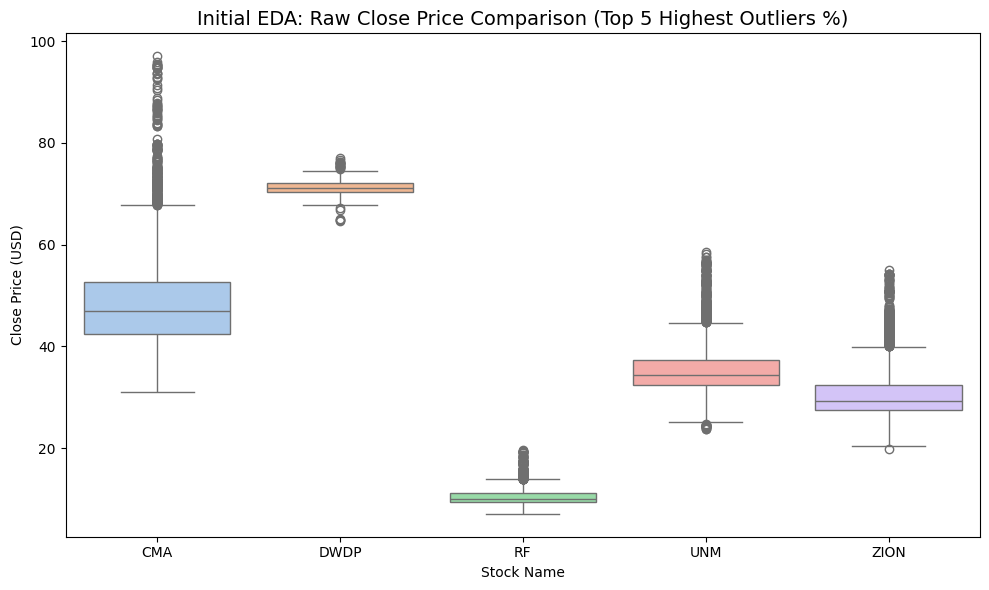

In [108]:
print("\n--- 📊 3.2 Initial EDA: Smart Box Plot (Auto-detect Outliers & Percentage) ---")

# 1. คำนวณหาขอบเขต Outlier (IQR)
Q1 = df.groupby('Name')['close'].quantile(0.25)
Q3 = df.groupby('Name')['close'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. เช็กแถวที่เป็น Outlier
df_outlier_check = df[['Name', 'close']].copy()
df_outlier_check['lower'] = df_outlier_check['Name'].map(lower_bound)
df_outlier_check['upper'] = df_outlier_check['Name'].map(upper_bound)
df_outlier_check['is_outlier'] = (df_outlier_check['close'] < df_outlier_check['lower']) | (df_outlier_check['close'] > df_outlier_check['upper'])

# 3. สรุปเป็นตาราง (นับจำนวน Outlier และจำนวนวันทั้งหมดของแต่ละหุ้น)
outlier_counts = df_outlier_check.groupby('Name')['is_outlier'].sum()
total_counts = df_outlier_check.groupby('Name')['close'].count()

# สร้าง DataFrame สรุป
df_summary = pd.DataFrame({
    'Outlier Count (Days)': outlier_counts,
    'Total Days': total_counts
})

# คำนวณหาเปอร์เซ็นต์
df_summary['Outlier %'] = (df_summary['Outlier Count (Days)'] / df_summary['Total Days']) * 100

# กรองเฉพาะหุ้นที่มี Outlier และเรียงตาม % จากมากไปน้อย
df_summary_filtered = df_summary[df_summary['Outlier Count (Days)'] > 0].sort_values(by='Outlier %', ascending=False)

print(f"🚨 สรุป: พบหุ้นที่มี Outlier ด้านราคา (Close) จำนวนทั้งหมด {len(df_summary_filtered)} บริษัท")
print("\n📋 ตารางรายชื่อหุ้นที่มี Outlier มากที่สุด 10 อันดับแรก (เรียงตามเปอร์เซ็นต์):")
# ใส่ .round(2) เพื่อให้ทศนิยมสวยๆ 2 ตำแหน่ง
display(df_summary_filtered.head(10).round(2))

# 4. ดึง Top 5 มาวาดกราฟ Box Plot ให้เห็นภาพ
top_5_outlier_stocks = df_summary_filtered.head(5).index.tolist()

if len(top_5_outlier_stocks) == 0:
    print("\n✅ ไม่พบข้อมูลที่เป็น Outlier เลย")
    stocks_to_plot = ['AAPL', 'MSFT', 'AMZN', 'AAL', 'DAL']
else:
    print(f"\n📈 นำหุ้น Top 5 ที่ราคาแกว่งที่สุดมาวาดกราฟ ได้แก่: {top_5_outlier_stocks}")
    stocks_to_plot = top_5_outlier_stocks

# 5. วาดกราฟ Box Plot
df_smart_sample = df[df['Name'].isin(stocks_to_plot)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Name', y='close', data=df_smart_sample, palette='pastel', hue='Name', legend=False)

plt.title('Initial EDA: Raw Close Price Comparison (Top 5 Highest Outliers %)', fontsize=14)
plt.ylabel('Close Price (USD)')
plt.xlabel('Stock Name')
plt.tight_layout()
plt.show()


--- 📊 3. Initial EDA: Data Distribution ---


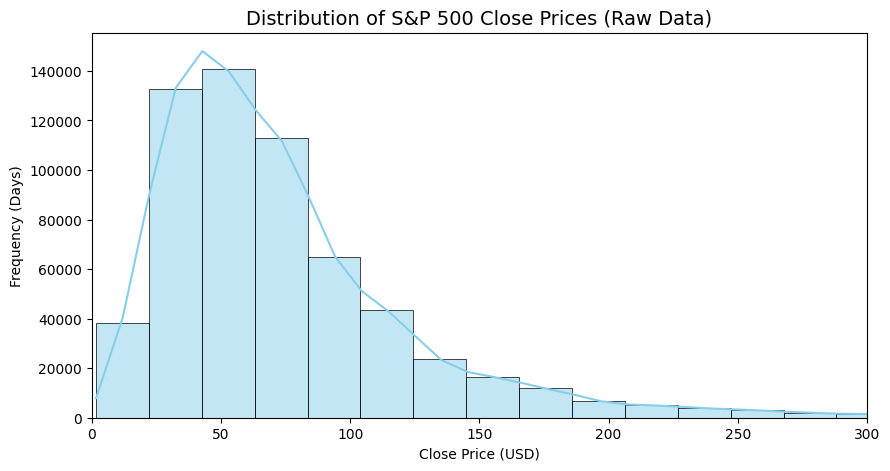

In [109]:
print("\n--- 📊 3. Initial EDA: Data Distribution ---")
# วาดกราฟฮิสโตแกรมเพื่อดูการกระจายตัวของราคาดิบ (ใช้ df ไม่ใช่ df_clean)
plt.figure(figsize=(10, 5))

# 🌟 แก้ไขเป็น df['close'] 
sns.histplot(df['close'], bins=100, color='skyblue', kde=True)

plt.title('Distribution of S&P 500 Close Prices (Raw Data)', fontsize=14)
plt.xlabel('Close Price (USD)')
plt.ylabel('Frequency (Days)')
plt.xlim(0, 300) # ซูมดูช่วงราคาที่คนส่วนใหญ่เทรดกัน
plt.show()

# Cleaning Data

In [110]:
# 1. เปลี่ยนคอลัมน์ date เป็นประเภท datetime
df['date'] = pd.to_datetime(df['date'])

# 2. เปลี่ยนคอลัมน์ Name เป็นประเภท string (ใน Pandas เวอร์ชันใหม่ๆ รองรับ 'string' แล้วครับ)
df['Name'] = df['Name'].astype('string')

# ตรวจสอบความถูกต้องหลังเปลี่ยนประเภทข้อมูล
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  string        
dtypes: datetime64[ns](1), float64(4), int64(1), string(1)
memory usage: 33.1 MB
None


In [111]:
# ========================================================
# 1. จัดการ Missing Values (ลบแถวที่มีค่าว่าง)
# ========================================================
print("--- 🔍 ก่อนลบ Missing Values ---")
print(df.isnull().sum())

# สร้างตัวแปร df_clean ขึ้นมาตรงนี้!
df_clean = df.dropna()

print(f"\n✅ ลบ Missing Values พื้นฐานเรียบร้อย เหลือ: {len(df_clean)} แถว")

# ========================================================
# 2. ขั้นตอนทำความสะอาดเพิ่มเติมสำหรับข้อมูล Time Series
# ========================================================
print("\n--- 🛠️ ขั้นตอนทำความสะอาดเพิ่มเติมสำหรับข้อมูล Time Series ---")

# 2.1 เรียงลำดับข้อมูลตามชื่อหุ้น (Name) และ วันที่ (date) จากอดีตไปปัจจุบัน
df_clean = df_clean.sort_values(by=['Name', 'date']).reset_index(drop=True)
print("✅ เรียงลำดับข้อมูลตามชื่อหุ้นและเวลาเรียบร้อยแล้ว")

# 2.2 แปลงข้อมูลราคา เป็น % Daily Return (เพื่อจัดการ Outlier สเกลราคา)
df_clean['daily_return_pct'] = df_clean.groupby('Name')['close'].pct_change() * 100

# 2.3 ลบ Missing Value อีกรอบ (เพราะวันแรกของหุ้นแต่ละตัวจะคำนวณ pct_change ไม่ได้)
df_clean = df_clean.dropna().reset_index(drop=True)

print(f"✅ แปลงราคาเป็น % Daily Return เรียบร้อย เหลือข้อมูลที่พร้อมที่สุด: {len(df_clean)} แถว")

# ดูผลลัพธ์ข้อมูลที่พร้อมที่สุด 5 แถวแรก
display(df_clean.head(20))

--- 🔍 ก่อนลบ Missing Values ---
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

✅ ลบ Missing Values พื้นฐานเรียบร้อย เหลือ: 619029 แถว

--- 🛠️ ขั้นตอนทำความสะอาดเพิ่มเติมสำหรับข้อมูล Time Series ---
✅ เรียงลำดับข้อมูลตามชื่อหุ้นและเวลาเรียบร้อยแล้ว
✅ แปลงราคาเป็น % Daily Return เรียบร้อย เหลือข้อมูลที่พร้อมที่สุด: 618524 แถว


,date,open,high,low,close,volume,Name,daily_return_pct
0,2013-02-11,45.17,45.180,44.450,44.60,2915405,A,-1.064774
1,2013-02-12,44.81,44.950,44.500,44.62,2373731,A,0.044843
2,2013-02-13,44.81,45.240,44.680,44.75,2052338,A,0.291349
3,2013-02-14,44.72,44.780,44.360,44.58,3826245,A,-0.379888
4,2013-02-15,43.48,44.240,42.210,42.25,14657315,A,-5.226559
5,2013-02-19,42.21,43.120,42.210,43.01,4116141,A,1.798817
6,2013-02-20,42.84,42.850,42.225,42.24,3873183,A,-1.790281
7,2013-02-21,42.14,42.140,41.470,41.63,3415149,A,-1.444129
8,2013-02-22,41.83,42.070,41.580,41.80,3354862,A,0.408359
9,2013-02-25,42.09,42.220,41.290,41.29,3622460,A,-1.220096



--- 🔍 พิสูจน์ความซ้ำซ้อนของข้อมูลดิบ (OHLCV) ---


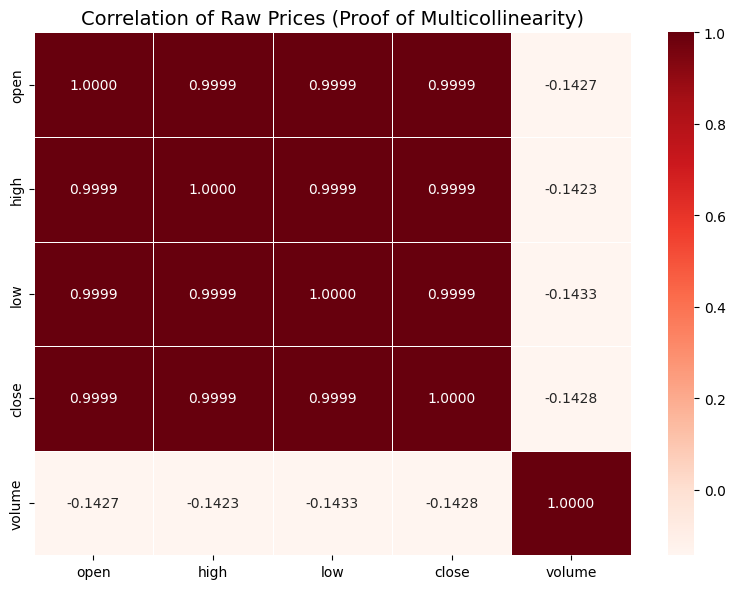

In [112]:
print("\n--- 🔍 พิสูจน์ความซ้ำซ้อนของข้อมูลดิบ (OHLCV) ---")

# ดูความสัมพันธ์ของราคาดิบ และ Volume
raw_features = ['open', 'high', 'low', 'close', 'volume']
corr_raw = df_clean[raw_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_raw, annot=True, cmap='Reds', fmt=".4f", linewidths=0.5)

plt.title('Correlation of Raw Prices (Proof of Multicollinearity)', fontsize=14)
plt.tight_layout()
plt.show()

# Features Engineering

In [113]:
print("--- 🚀 เริ่มกระบวนการ Feature Engineering (Basic + Advanced) ---")

# 0. คำนวณ Log Return
df_clean['log_return'] = np.log(df_clean['close'] / df_clean.groupby('Name')['close'].shift(1))

# ========================================================
# 🟢 ส่วนที่ 1: Basic Features (ความจำระยะสั้น & ปฏิทิน)
# ========================================================
df_clean['lag_1_return'] = df_clean.groupby('Name')['log_return'].shift(1)
df_clean['lag_3_return'] = df_clean.groupby('Name')['log_return'].shift(3)
df_clean['lag_7_return'] = df_clean.groupby('Name')['log_return'].shift(7)

df_clean['SMA_7'] = df_clean.groupby('Name')['close'].transform(lambda x: x.rolling(window=7).mean())
df_clean['Volatility_7'] = df_clean.groupby('Name')['log_return'].transform(lambda x: x.rolling(window=7).std())

df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
df_clean['month'] = df_clean['date'].dt.month
df_clean['quarter'] = df_clean['date'].dt.quarter
df_clean['is_month_end'] = df_clean['date'].dt.is_month_end.astype(int)

# ========================================================
# 🔴 ส่วนที่ 2: Advanced Features (เทคนิคคอล & เทียบภาพรวมตลาด)
# ========================================================
df_clean['EMA_14'] = df_clean.groupby('Name')['close'].transform(lambda x: x.ewm(span=14, adjust=False).mean())

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df_clean['RSI_14'] = df_clean.groupby('Name')['close'].transform(calculate_rsi)

ema_12 = df_clean.groupby('Name')['close'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema_26 = df_clean.groupby('Name')['close'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df_clean['MACD'] = ema_12 - ema_26

market_return = df_clean.groupby('date')['log_return'].mean().rename('Market_Return')
df_clean = df_clean.merge(market_return, on='date', how='left')
df_clean['Relative_Return'] = df_clean['log_return'] - df_clean['Market_Return']

stock_volatility = df_clean.groupby('Name')['log_return'].std().rename('Stock_Historical_Vol')
df_clean = df_clean.merge(stock_volatility, on='Name', how='left')

# ========================================================
# 🎯 ส่วนที่ 3: สร้าง Target Variable (เฉลยข้อสอบ)
# ========================================================
print("--- 🎯 กำลังสร้างเฉลยข้อสอบ (Target Variable) ---")
df_clean['Target_Next_Day_Return'] = df_clean.groupby('Name')['log_return'].shift(-1)
df_clean['Target_Direction'] = (df_clean['Target_Next_Day_Return'] > 0).astype(int)

# ========================================================
# 🧹 ส่วนที่ 4: จัดการแถวที่เกิดค่าว่าง (NaN) รวดเดียวจบ
# ========================================================
df_final = df_clean.dropna().reset_index(drop=True)

print(f"✅ สร้าง Features และ Target เสร็จสมบูรณ์! ได้ตัวแปรมาทั้งหมด {len(df_final.columns)} ตัวแปร")
print(f"✅ ข้อมูลพร้อมเข้าโมเดล (เหลือจำนวน {len(df_final)} แถว)")

# ดูหน้าตาข้อมูลที่พร้อมที่สุด
pd.set_option('display.max_columns', None) 
display(df_final.head())

--- 🚀 เริ่มกระบวนการ Feature Engineering (Basic + Advanced) ---
--- 🎯 กำลังสร้างเฉลยข้อสอบ (Target Variable) ---
✅ สร้าง Features และ Target เสร็จสมบูรณ์! ได้ตัวแปรมาทั้งหมด 26 ตัวแปร
✅ ข้อมูลพร้อมเข้าโมเดล (เหลือจำนวน 611454 แถว)


,date,open,high,low,close,volume,Name,daily_return_pct,log_return,lag_1_return,lag_3_return,lag_7_return,SMA_7,Volatility_7,day_of_week,month,quarter,is_month_end,EMA_14,RSI_14,MACD,Market_Return,Relative_Return,Stock_Historical_Vol,Target_Next_Day_Return,Target_Direction
0,2013-03-01,41.18,41.98,40.73,41.93,3089323,A,1.084860,0.010790,-0.006009,-0.007780,-0.018065,41.547143,0.012397,4,3,1,0,42.416158,31.586207,-0.825350,0.002460,0.008330,0.016088,0.002382,1
1,2013-03-04,41.75,42.18,41.52,42.03,2435306,A,0.238493,0.002382,0.010790,0.018380,-0.014547,41.604286,0.010884,0,3,1,0,42.364670,32.517007,-0.782489,0.005030,-0.002648,0.016088,0.014878,1
2,2013-03-05,42.35,43.19,42.34,42.66,3289188,A,1.498929,0.014878,0.002382,-0.006009,0.004075,41.727143,0.012037,1,3,1,0,42.404048,37.688442,-0.689734,0.010097,0.004781,0.016088,0.013504,1
3,2013-03-06,43.00,43.52,42.90,43.24,2996908,A,1.359587,0.013504,0.014878,0.010790,-0.012276,42.005714,0.010457,2,3,1,0,42.515508,41.022592,-0.562936,0.001238,0.012266,0.016088,0.000231,1
4,2013-03-07,43.30,43.48,42.81,43.25,2414186,A,0.023127,0.000231,0.013504,0.002382,-0.007780,42.331429,0.008952,3,3,1,0,42.613440,41.939394,-0.456379,0.001476,-0.001244,0.016088,-0.005100,0


In [114]:
display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 618524 entries, 0 to 618523
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date                    618524 non-null  datetime64[ns]
 1   open                    618524 non-null  float64       
 2   high                    618524 non-null  float64       
 3   low                     618524 non-null  float64       
 4   close                   618524 non-null  float64       
 5   volume                  618524 non-null  int64         
 6   Name                    618524 non-null  string        
 7   daily_return_pct        618524 non-null  float64       
 8   log_return              618019 non-null  float64       
 9   lag_1_return            617514 non-null  float64       
 10  lag_3_return            616504 non-null  float64       
 11  lag_7_return            614484 non-null  float64       
 12  SMA_7                   615494

None


--- 🔍 5. ตรวจสอบความซ้ำซ้อนของตัวแปร (Correlation Heatmap) ---


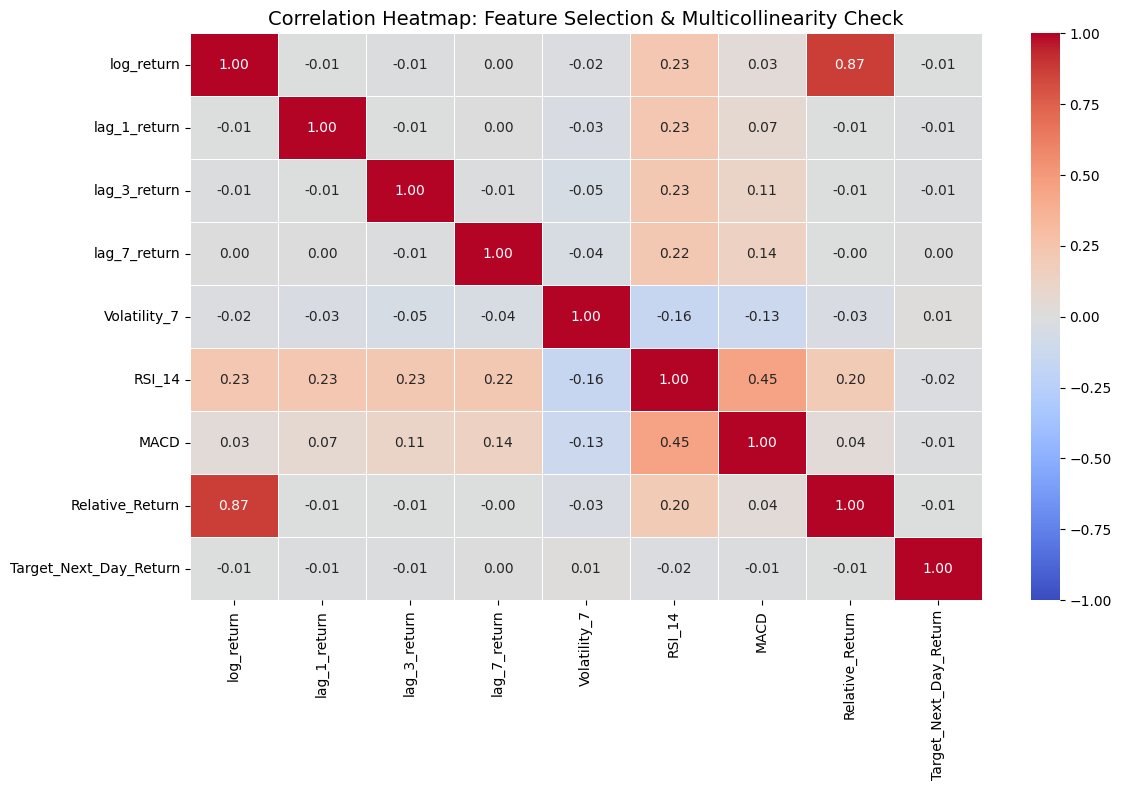

In [115]:
print("\n--- 🔍 5. ตรวจสอบความซ้ำซ้อนของตัวแปร (Correlation Heatmap) ---")

# 1. เลือกเฉพาะคอลัมน์ที่เป็นตัวเลข (คำใบ้ของเรา + เฉลยข้อสอบ) มาเช็ก
features_to_check = [
    'log_return', 'lag_1_return', 'lag_3_return', 'lag_7_return', 
    'Volatility_7', 'RSI_14', 'MACD', 'Relative_Return', 
    'Target_Next_Day_Return' # ใช้ผลตอบแทนจริงมาดูความสัมพันธ์จะเห็นชัดกว่า
]

# 2. คำนวณ Correlation (ใช้ df_final ที่ไม่มีค่าว่างแล้ว)
corr_matrix = df_final[features_to_check].corr()

# 3. วาดกราฟ Heatmap
plt.figure(figsize=(12, 8))

# ใช้ sns.heatmap (annot=True คือให้โชว์ตัวเลข, cmap='coolwarm' คือโทนสีเย็นไปร้อน)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Correlation Heatmap: Feature Selection & Multicollinearity Check', fontsize=14)
plt.tight_layout()
plt.show()

# Data Splitting

In [122]:
print("--- ✂️ 6. Data Splitting: แบ่งข้อมูลอดีตเพื่อทำนายอนาคต ---")

# 1. 🌟 สับเปลี่ยนวิธีเรียงลำดับ: ต้องเรียงตาม "วันที่" ก่อน (ป้องกันการแบ่งหุ้นขาดออกจากกัน)
df_final = df_final.sort_values(by='date').reset_index(drop=True)

# 2. คัดกรองตัวแปร: เลือกว่าอะไรคือ "คำใบ้ (X)" และอะไรคือ "เฉลย (y)"
# เราจะทิ้งคอลัมน์ที่ไม่เกี่ยวกับการทำนาย หรือคอลัมน์ที่เป็นอนาคตออกไป
cols_to_drop = [
    'date', 'Name',          # ข้อมูลพื้นฐาน ไม่ใช่คำใบ้ตัวเลข
    'open', 'high', 'low', 'close', 'volume', # ข้อมูลดิบที่ซ้ำซ้อน (เราแปลงเป็น Feature หมดแล้ว)
    'Target_Next_Day_Return', 'Target_Direction' # อันนี้คือเฉลยข้อสอบ ห้ามให้โมเดลเห็นตอนเรียน!
]

# สร้างตารางคำใบ้ (X) และ เฉลย (y)
X = df_final.drop(columns=cols_to_drop)
y = df_final['Target_Direction']

# 3. แบ่งข้อมูล Train (80%) และ Test (20%)
# 🌟 บังคับ shuffle=False เพื่อให้ 80% แรกคืออดีต และ 20% หลังคืออนาคต
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"✅ แบ่งข้อมูลสำเร็จ (Train 80%, Test 20%)")
print(f"📚 ข้อมูลสำหรับเรียนรู้ (Train): {X_train.shape[0]} แถว | จำนวนคำใบ้: {X_train.shape[1]} ตัวแปร")
print(f"🎯 ข้อมูลสำหรับทดสอบ (Test): {X_test.shape[0]} แถว")

# 4. เช็กวันที่เพื่อความชัวร์ว่าเราไม่ได้โกงเวลา
train_start = df_final.iloc[X_train.index[0]]['date'].strftime('%Y-%m-%d')
train_end = df_final.iloc[X_train.index[-1]]['date'].strftime('%Y-%m-%d')
test_start = df_final.iloc[X_test.index[0]]['date'].strftime('%Y-%m-%d')
test_end = df_final.iloc[X_test.index[-1]]['date'].strftime('%Y-%m-%d')

print(f"\n🗓️ ไทม์ไลน์ชุด Train: {train_start} ถึง {train_end}")
print(f"🗓️ ไทม์ไลน์ชุด Test:  {test_start} ถึง {test_end}")

--- ✂️ 6. Data Splitting: แบ่งข้อมูลอดีตเพื่อทำนายอนาคต ---
✅ แบ่งข้อมูลสำเร็จ (Train 80%, Test 20%)
📚 ข้อมูลสำหรับเรียนรู้ (Train): 489163 แถว | จำนวนคำใบ้: 17 ตัวแปร
🎯 ข้อมูลสำหรับทดสอบ (Test): 122291 แถว

🗓️ ไทม์ไลน์ชุด Train: 2013-03-01 ถึง 2017-02-17
🗓️ ไทม์ไลน์ชุด Test:  2017-02-17 ถึง 2018-02-06


# Feature Selection

--- 🌟 7. Feature Selection: คัดเลือกคำใบ้ที่บอกอนาคตได้ดีที่สุด ---
📋 ตารางคะแนนความสำคัญของตัวแปร (Top 10):


,Feature,Importance
14,Market_Return,0.113362
4,lag_7_return,0.075946
2,lag_1_return,0.075882
3,lag_3_return,0.075482
12,RSI_14,0.071945
6,Volatility_7,0.071387
13,MACD,0.070046
16,Stock_Historical_Vol,0.067775
15,Relative_Return,0.065248
5,SMA_7,0.059227


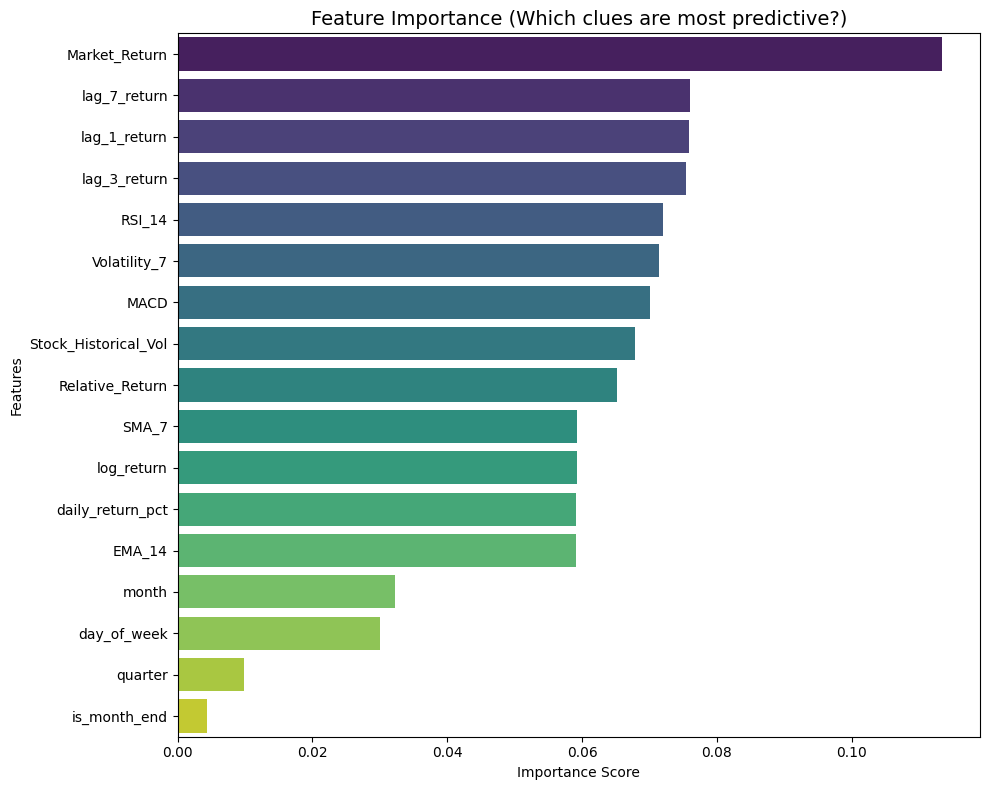


✅ หั่นตัวแปรขยะทิ้งเรียบร้อย! เราจะใช้ Top 10 Features นี้เข้าสู่โมเดลจริง:
['Market_Return', 'lag_7_return', 'lag_1_return', 'lag_3_return', 'RSI_14', 'Volatility_7', 'MACD', 'Stock_Historical_Vol', 'Relative_Return', 'SMA_7']


In [123]:
from sklearn.ensemble import RandomForestClassifier

print("--- 🌟 7. Feature Selection: คัดเลือกคำใบ้ที่บอกอนาคตได้ดีที่สุด ---")

# 1. สร้างโมเดล Random Forest แบบพื้นฐานเพื่อใช้สแกนหาตัวแปรสำคัญ
# (n_jobs=-1 คือการสั่งให้ CPU ทุกคอร์ช่วยกันประมวลผล จะได้เสร็จไวๆ)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# 2. ดึงค่าคะแนนความสำคัญ (Feature Importances) ออกมา
importances = rf_selector.feature_importances_

# 3. สร้างตารางเรียงลำดับคะแนนจากมากไปน้อย
feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("📋 ตารางคะแนนความสำคัญของตัวแปร (Top 10):")
display(feature_imp_df.head(10))

# 4. วาดกราฟ Bar Plot แนวนอนให้ดูสวยงามและเป็นมืออาชีพ
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis', hue='Feature', legend=False)

plt.title('Feature Importance (Which clues are most predictive?)', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 5. คัดเลือกเอาเฉพาะ Top 10 Features ที่ดีที่สุดไปใช้งานต่อ
top_10_features = feature_imp_df['Feature'].head(10).tolist()

# อัปเดตชุดข้อมูล Train/Test ให้เหลือแค่ 10 ตัวท็อป
X_train_selected = X_train[top_10_features]
X_test_selected = X_test[top_10_features]

print(f"\n✅ หั่นตัวแปรขยะทิ้งเรียบร้อย! เราจะใช้ Top 10 Features นี้เข้าสู่โมเดลจริง:")
print(top_10_features)

# Model Training

--- 🚀 เริ่มกระบวนการ Train, Tune และ Compare โมเดล (Fast Mode) ---
⏳ 1. กำลังจูนพารามิเตอร์ Random Forest...
✅ จูน RF เสร็จสิ้น! (Best Params: {'rf__n_estimators': 50, 'rf__min_samples_split': 5, 'rf__max_depth': 5})

⏳ 2. กำลังเทรนและเปรียบเทียบ 4 โมเดล...


C:\Users\lovea\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



🏆 โมเดลที่ทำความแม่นยำได้สูงที่สุดคือ: **Random Forest (Tuned)**
🌟 ด้วยความแม่นยำ (Test Accuracy): 51.87%



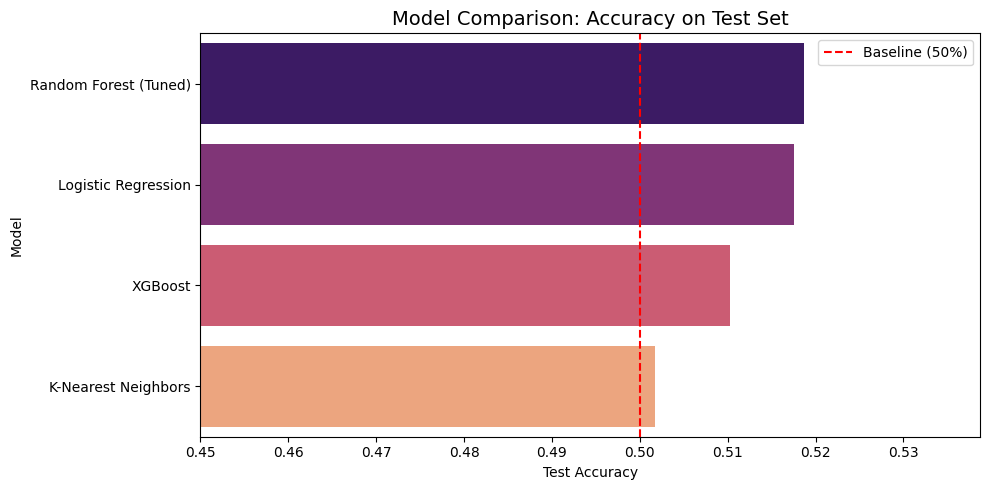


📋 รายงานผลการสอบอย่างละเอียดของแชมป์เปี้ยน (Random Forest (Tuned)):
              precision    recall  f1-score   support

           0       0.49      0.27      0.35     58258
           1       0.53      0.75      0.62     64033

    accuracy                           0.52    122291
   macro avg       0.51      0.51      0.48    122291
weighted avg       0.51      0.52      0.49    122291



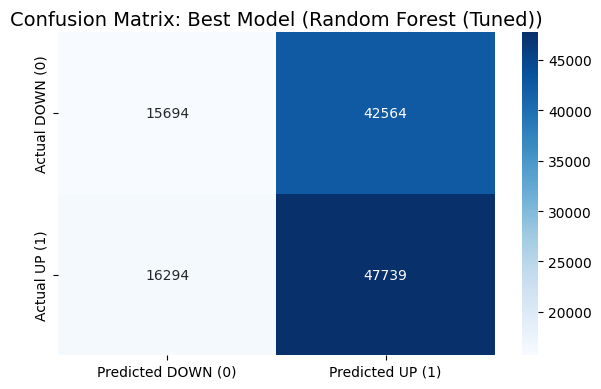

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 🚀 เริ่มกระบวนการ Train, Tune และ Compare โมเดล (Fast Mode) ---")

# ==========================================
# 🟢 1. จูน Random Forest แบบด่วน (Fast Hyperparameter Tuning)
# ==========================================
print("⏳ 1. กำลังจูนพารามิเตอร์ Random Forest...")
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)) # ใช้ CPU ทุกคอร์
])

# ปรับลด Space ให้รันไวขึ้น
param_distributions = {
    'rf__n_estimators': [50, 100],         
    'rf__max_depth': [5, 10],          
    'rf__min_samples_split': [5, 10]
}

# ลด n_splits เหลือ 2 เพื่อความรวดเร็ว
random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distributions,
    n_iter=3,                # สุ่มแค่ 3 แบบพอครับ
    cv=TimeSeriesSplit(n_splits=2), 
    scoring='accuracy',      
    random_state=42,
    n_jobs=-1                
)

random_search.fit(X_train_selected, y_train)
best_rf_model = random_search.best_estimator_
print(f"✅ จูน RF เสร็จสิ้น! (Best Params: {random_search.best_params_})")

# ==========================================
# 🔵 2. กำหนดโมเดล 4 มหาอำนาจ (จับใส่ Scaler ให้หมดเพื่อความเร็วและแม่นยำ)
# ==========================================
print("\n⏳ 2. กำลังเทรนและเปรียบเทียบ 4 โมเดล...")
models = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, n_jobs=-1))]),
    "K-Nearest Neighbors": Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
    "Random Forest (Tuned)": best_rf_model,
    "XGBoost": Pipeline([('scaler', StandardScaler()), ('xgb', XGBClassifier(n_estimators=50, learning_rate=0.1, random_state=42, n_jobs=-1))])
}

results = []
best_accuracy = 0
best_model_name = ""
best_predictions = None

# ==========================================
# 🟡 3. วนลูปเทรน วัดผล และหาแชมป์เปี้ยน
# ==========================================
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({"Model": name, "Test Accuracy": acc})
    
    # เก็บข้อมูลของโมเดลที่แม่นยำที่สุดไว้
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_predictions = y_pred

# สร้างตารางสรุปผล
df_results = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)

# ==========================================
# 🔴 4. แสดงผลลัพธ์และการประกาศรางวัล
# ==========================================
print("\n" + "="*50)
print(f"🏆 โมเดลที่ทำความแม่นยำได้สูงที่สุดคือ: **{best_model_name}**")
print(f"🌟 ด้วยความแม่นยำ (Test Accuracy): {best_accuracy*100:.2f}%")
print("="*50 + "\n")

# วาดกราฟเปรียบเทียบ
plt.figure(figsize=(10, 5))
sns.barplot(x='Test Accuracy', y='Model', data=df_results, palette='magma', hue='Model', legend=False)
plt.axvline(0.5, color='red', linestyle='--', label='Baseline (50%)')
plt.title('Model Comparison: Accuracy on Test Set', fontsize=14)
plt.xlim(0.45, max(df_results['Test Accuracy']) + 0.02) # ปรับแกน X อัตโนมัติ
plt.legend()
plt.tight_layout()
plt.show()

# พิมพ์ Classification Report และ Confusion Matrix ของโมเดลที่ชนะ
print(f"\n📋 รายงานผลการสอบอย่างละเอียดของแชมป์เปี้ยน ({best_model_name}):")
print(classification_report(y_test, best_predictions))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted DOWN (0)', 'Predicted UP (1)'],
            yticklabels=['Actual DOWN (0)', 'Actual UP (1)'])
plt.title(f'Confusion Matrix: Best Model ({best_model_name})', fontsize=14)
plt.tight_layout()
plt.show()

# Steamlit

In [127]:
import joblib
import json

print("--- 💾 11. Export Model & Metadata สำหรับทำ Web App (Streamlit) ---")

# 1. ดึงโมเดลที่ชนะเลิศจากลูปเปรียบเทียบเมื่อกี้
champion_model = models[best_model_name]

# 2. บันทึก Model (ตัวที่อยู่ใน Pipeline มี Scaler เรียบร้อยแล้ว)
joblib.dump(champion_model, 'stock_champion_model.pkl')
print("✅ บันทึกโมเดล: stock_champion_model.pkl")

# 3. บันทึกชื่อตัวแปร (Features) ที่โมเดลต้องการใช้รับค่าจากหน้าเว็บ
features_list = list(X_train_selected.columns)
with open('stock_features.json', 'w') as f:
    json.dump(features_list, f)
print(f"✅ บันทึกชื่อตัวแปร ({len(features_list)} ตัว): stock_features.json")

# 4. บันทึก Metadata (ข้อมูลสรุปของโมเดลเอาไปโชว์บนเว็บ)
metadata = {
    "model_name": best_model_name,
    "test_accuracy": round(best_accuracy, 4),
    "features_count": len(features_list),
    "description": "Stock Daily Direction Prediction (1 = UP trend, 0 = DOWN trend)"
}
with open('stock_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)
print("✅ บันทึก Metadata: stock_metadata.json")

--- 💾 11. Export Model & Metadata สำหรับทำ Web App (Streamlit) ---
✅ บันทึกโมเดล: stock_champion_model.pkl
✅ บันทึกชื่อตัวแปร (10 ตัว): stock_features.json
✅ บันทึก Metadata: stock_metadata.json


In [128]:
import json

# 1. ดึงรายชื่อหุ้นที่ไม่ซ้ำกันจากคอลัมน์ 'Name'
all_tickers = df_final['Name'].unique().tolist()

# 2. เรียงลำดับตัวอักษร A-Z ให้ผู้ใช้หาเปิดหาง่ายๆ
all_tickers.sort()

# 3. เซฟเป็นไฟล์ JSON
with open('ticker_list.json', 'w') as f:
    json.dump(all_tickers, f)

print(f"✅ บันทึกรายชื่อหุ้นทั้งหมด {len(all_tickers)} ตัว ลงในไฟล์ ticker_list.json สำเร็จ!")

✅ บันทึกรายชื่อหุ้นทั้งหมด 505 ตัว ลงในไฟล์ ticker_list.json สำเร็จ!
